In [13]:
import xarray as xr
import numpy as np
from typing import Tuple
from matplotlib import pyplot as plt

def process_TraCE_data(
    nc_path: str,
    df_pre,
    initial_age_offset: int = 22,
    age_start: int = 100,
    age_end: int = 22000,
    age_step: int = 200,
    age_offset: int = 2000,
    smooth_window: int = 10
) -> Tuple[xr.Dataset, xr.Dataset]:
    """
    Load a TraCE .nc file, rename and convert units, interpolate ages,
    apply a centered moving average, compute differences, and return both
    the processed (diff) dataset and a cropped ‘pre’ dataset.
    
    Parameters
    ----------
    nc_path : str
        Path to the TraCE .nc file.
    age_start : int, optional
        Starting age (years BP) for interpolation, by default 100.
    age_end : int, optional
        Ending age (years BP) for interpolation, by default 22000.
    age_step : int, optional
        Step size (years) for interpolation, by default 200.
    smooth_window : int, optional
        Window length (in samples) for the centered moving average, by default 10.
    
    Returns
    -------
    processed : xr.Dataset
        Dataset with variable `sat_diff` (smoothed difference).
        Coordinates: age, lat, lon.
    pre_cropped : xr.Dataset
        The same `sat_diff` dataset cropped between its first and last age.
    """
    # 1. Load & rename
    ds = xr.open_dataset(nc_path)
    ds = ds.rename({'TREFHT': 'sat', 'time': 'age'})
    
    # 2. Convert age units (from model time to years BP) and temperature to °C
    ds['age'] = (ds['age'] + initial_age_offset) * 1000
    ds['sat'] = ds['sat'] - 273.15

    ds['sat'].isel(lat=7, lon=0).plot()

    ds['sat'] = (
        ds['sat']
        .rolling(age=200, center=True, min_periods=1)
        .mean()
    )
    
    ds['sat'].isel(lat=7, lon=0).plot()

    # 3. Subset to only the SAT variable
    ds = ds[['sat']]

    # ds['sat'].isel(lat=7, lon=0).plot()
    
    # 4. Interpolate to a regular age grid
    new_ages = np.arange(age_start, age_end, age_step)
    ds = ds.interp(age=new_ages)
    # print(ds.age.values)
    
    # # 5. Smooth with a centered moving average
    # ds_smoothed = (
    #     ds['sat']
    #     .rolling(age=smooth_window, center=True, min_periods=1)
    #     .mean()
    # )
    
    # # 6. Compute the difference along age
    # diff = ds_smoothed.diff(dim='age')


    diff = ds['sat'].diff(dim='age')

    # # smooth the difference
    # diff = (
    #     diff
    #     .rolling(age=smooth_window, center=True, min_periods=1)
    #     .mean()
    # )



    
    # 7. Build a new Dataset for the diff, adjusting the age coordinate
    raw_ages = ds.age.values
    diff_ages = raw_ages[1:] + age_offset  # shift ages to midpoint if desired
    processed = xr.Dataset(
        {'sat_diff': (('age', 'lat', 'lon'), diff.values)},
        coords={'age': diff_ages, 'lat': ds.lat, 'lon': ds.lon}
    )
    plt.figure()
    processed['sat_diff'].isel(lat=7, lon=0).plot()
    # print(processed.age.values)
    # 8. Crop “pre” data over its full range
    # pre_cropped = processed.sel(age=slice(processed.age[0], processed.age[-1]))
    # pre_cropped = df_pre[(df_pre['age'] >= processed.age[0].values) &
    #                      (df_pre['age'] <= processed.age[-1].values)]
    # use the time of processed data to interpolate the pre data uising np and store the pre cropped data as a data frame
    age_interp= processed.age.values
    pre_interp = np.interp(age_interp, df_pre['age'].values, df_pre['pre'].values)
    # create a new data frame with the interpolated values
    import pandas as pd
    pre_cropped = pd.DataFrame({'age': age_interp, 'pre': pre_interp})
    
    return processed, pre_cropped


# Orb

In [6]:
ds_orb

<xarray.Dataset>
Dimensions:   (age: 54, lat: 48, lon: 96)
Coordinates:
  * age       (age) int32 2700 3100 3500 3900 4300 ... 22700 23100 23500 23900
  * lat       (lat) float64 -87.16 -83.48 -79.78 -76.07 ... 79.78 83.48 87.16
  * lon       (lon) float64 0.0 3.75 7.5 11.25 15.0 ... 345.0 348.8 352.5 356.2
Data variables:
    sat_diff  (age, lat, lon) float64 0.02129 0.02202 ... -0.06563 -0.06731

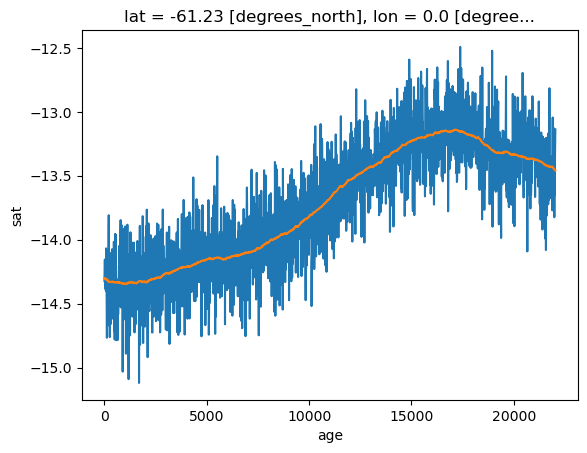

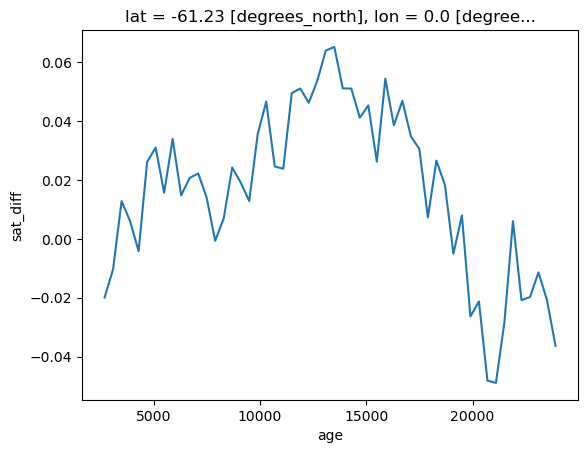

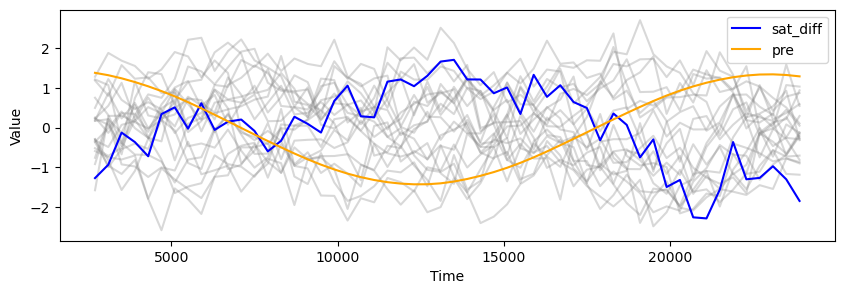

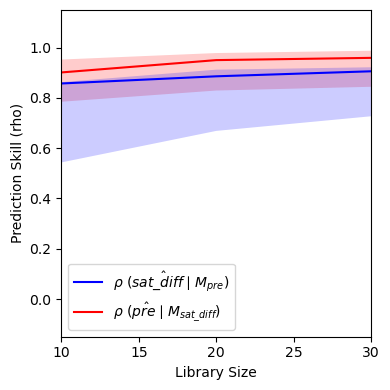

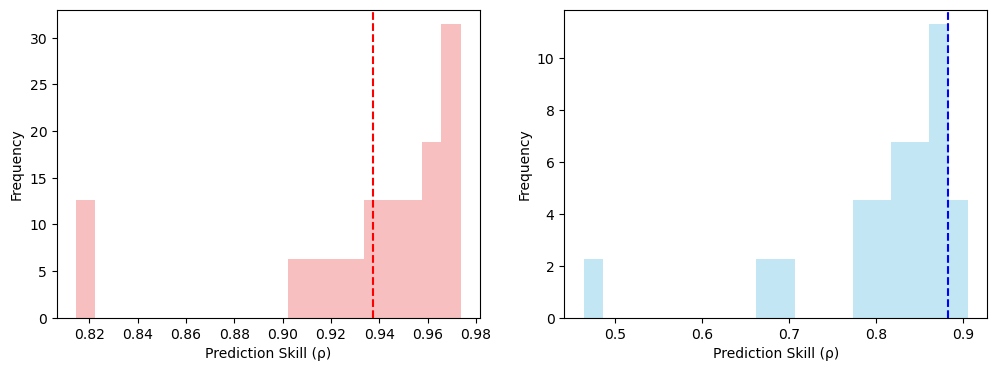

(False, False)


CCM v3:   0%|          | 0/4608 [00:00<?, ?it/s]

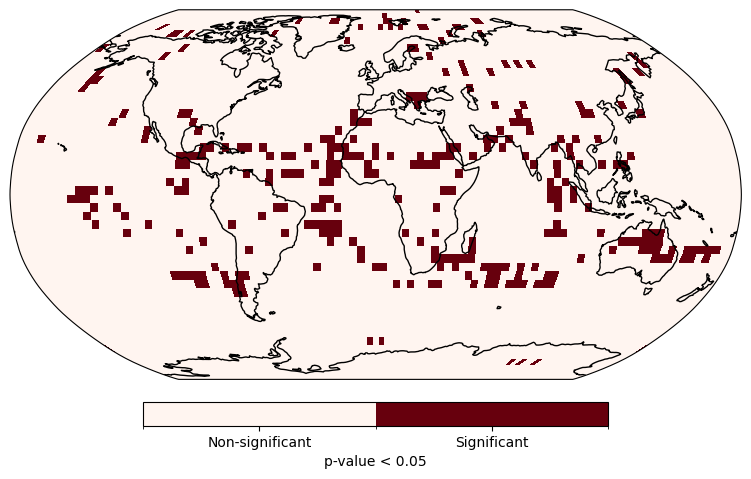

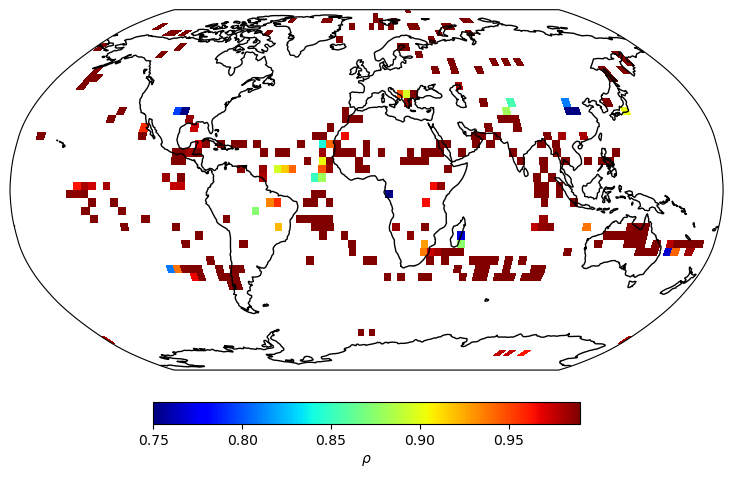

In [17]:
import pandas as pd

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

# ds_orb,orb_pre=process_TraCE_data(nc_path= 'D:/VScode/Last_deglaciation/TraCE_data/b30.00_4kaDVTj.cam2.ncrcat.ann.nc',
#                         df_pre=df_pre,
#                         initial_age_offset=22,
#                         age_start=100,
#                         age_end=22000,
#                         age_step=200,
#                         age_offset=2000,
#                         smooth_window=10)


ds_orb,orb_pre=process_TraCE_data(nc_path= 'D:/VScode/Last_deglaciation/TraCE_data/b30.00_4kaDVTj.cam2.ncrcat.ann.nc',
                        df_pre=df_pre,
                        initial_age_offset=22,
                        age_start=100,
                        age_end=22000,
                        age_step=400,
                        age_offset=2200,
                        smooth_window=10)





from toolbox import significant_test as st
import importlib
importlib.reload(st)



ccm_out, ran_ccm_list_xy, test_result=st.ccm_significance_test_v3(ds_orb, orb_pre, lat_idx=7, lon_idx=0,
    E=5, 
    tau=-4, 
    n_ran=20, 
    libSizes="10 20 30",
    Tp=0,
    sample=10,
    random =True,
    flip_pre= False,
    showPlot=True
)

print(test_result)




# from toolbox import Tp_ana as ta
# import importlib
# importlib.reload(ta)
 

# # df_AT_diff = df_AT_diff.rename(columns={'age': 'age', 'sat_diff': 'sat_diff'})
# Tps_list, forward_rhos, reverse_rhos = ta.find_optimal_Tp(
#     df_sd      = ds_orb,
#     df_pre     = df_pre,
#     E          = 4,
#     tau        = -2,
#     libSizes   = "100",
#     sample     = 100,
#     Tps        = range(-10, 11),
#     interactive=True   
# )




from toolbox import significant_map  as sm
import importlib
importlib.reload(sm)
import pickle


sig_map,rho_map=sm.sig_map_rho_allinone(ds_orb, orb_pre,
                                   E=5, tau=-5, Tp=0, libSizes="10 20 30",
                                   n_ran=20, sample=20, random=True, function='v3', mode='bi', show_figure=True)



from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

processed_rho_map=cm.postprocess_rho_map(rho_map, sig_map)
cm.plot_rho_map(processed_rho_map, ds_orb, v_range=[0.75, 0.99], color_map='jet')

# save processed_rho_map_Tp0_uncertainty_ana
with open("output/processed_rho_map_Tp0_TraCE_orb.pkl", "wb") as f:
    pickle.dump(processed_rho_map, f)


In [76]:
ds_orb

<xarray.Dataset>
Dimensions:   (age: 109, lat: 48, lon: 96)
Coordinates:
  * age       (age) int32 2300 2500 2700 2900 3100 ... 23300 23500 23700 23900
  * lat       (lat) float64 -87.16 -83.48 -79.78 -76.07 ... 79.78 83.48 87.16
  * lon       (lon) float64 0.0 3.75 7.5 11.25 15.0 ... 345.0 348.8 352.5 356.2
Data variables:
    sat_diff  (age, lat, lon) float64 0.002697 0.002892 ... -0.008835 -0.008083

In [77]:
orb_pre

,age,pre
10,2300.0,0.018153
11,2500.0,0.017913
12,2700.0,0.017610
13,2900.0,0.017244
14,3100.0,0.016815
...,...,...
114,23100.0,0.017104
115,23300.0,0.017029
116,23500.0,0.016891
117,23700.0,0.016690


In [25]:
ds_orb

<xarray.Dataset>
Dimensions:   (age: 109, lat: 48, lon: 96)
Coordinates:
  * age       (age) int32 500 700 900 1100 1300 ... 21500 21700 21900 22100
  * lat       (lat) float64 -87.16 -83.48 -79.78 -76.07 ... 79.78 83.48 87.16
  * lon       (lon) float64 0.0 3.75 7.5 11.25 15.0 ... 345.0 348.8 352.5 356.2
Data variables:
    sat_diff  (age, lat, lon) float64 -0.08271 -0.08228 ... 0.00394 0.007685

# GHG

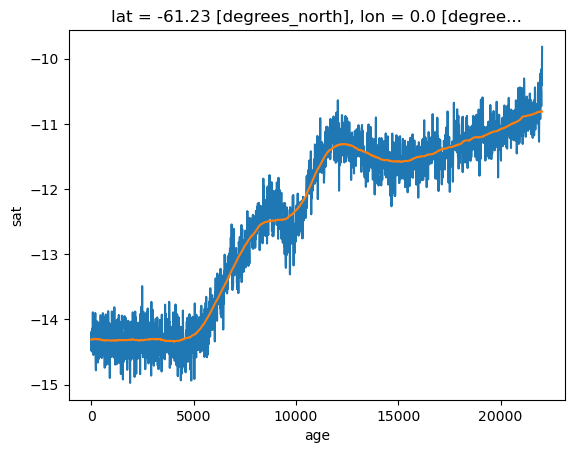

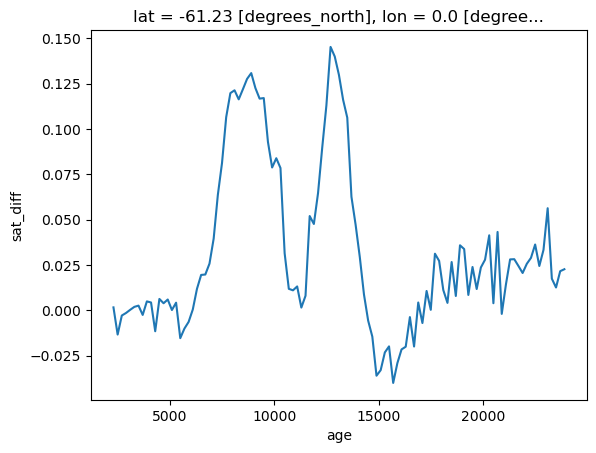

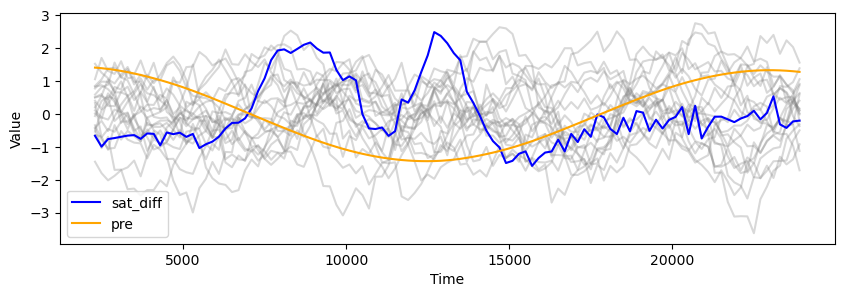

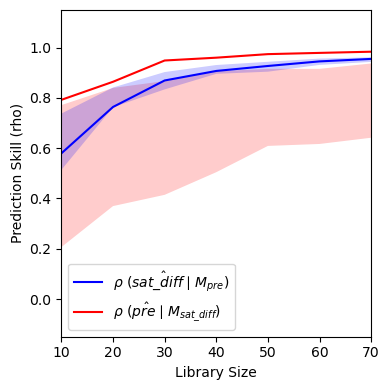

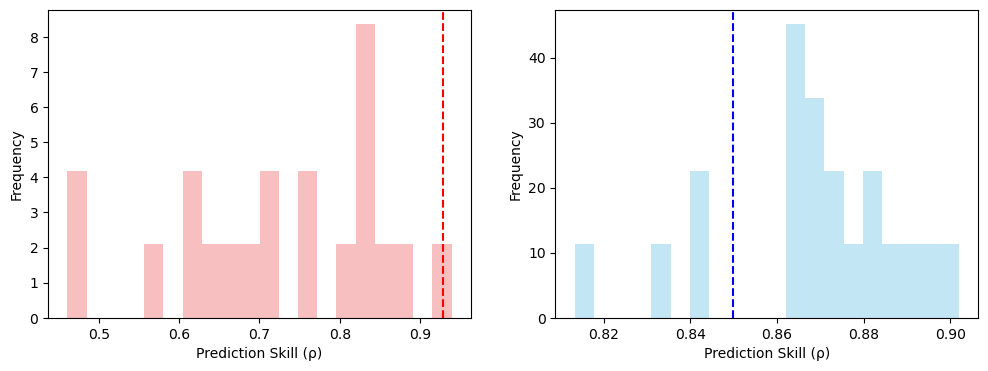

(True, False)


CCM v3:   0%|          | 0/4608 [00:00<?, ?it/s]

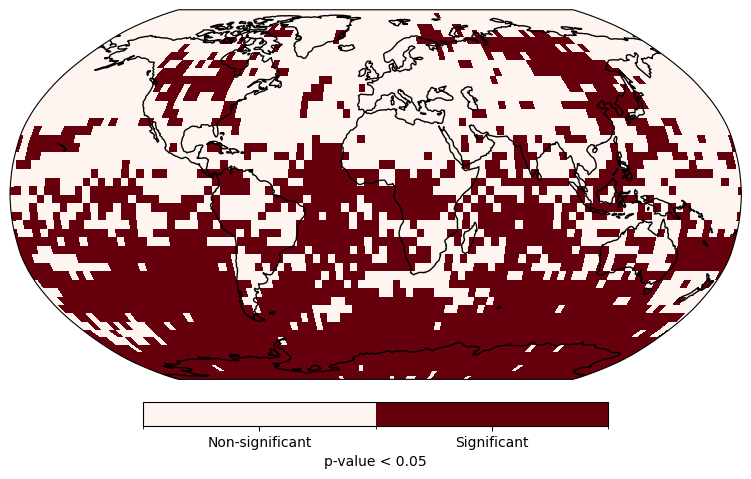

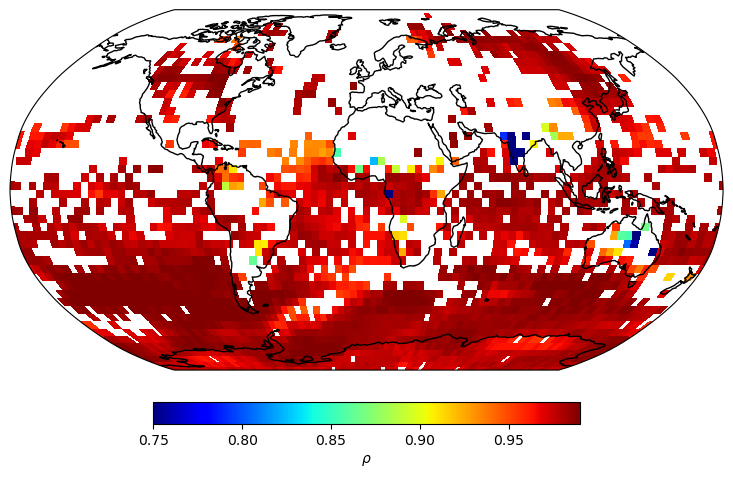

In [106]:
import pandas as pd

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

ds_ghg,ghg_pre=process_TraCE_data(nc_path= 'E:/TraCE_original_data/b30.00_4kaDVTk.cam2.ncrcat.ann_original_backup.nc',
                        df_pre=df_pre,
                        initial_age_offset=22,
                        age_start=100,
                        age_end=22000,
                        age_step=200,
                        age_offset=2000,
                        smooth_window=10)




from toolbox import significant_test as st
import importlib
importlib.reload(st)



ccm_out, ran_ccm_list_xy, test_result=st.ccm_significance_test_v3(ds_ghg, ghg_pre, lat_idx=7, lon_idx=0,
    E=5, 
    tau=-4, 
    n_ran=20, 
    libSizes="10 20 30 40 50 60 70",
    Tp=0,
    sample=10,
    random =True,
    flip_pre= False,
    showPlot=True
)

print(test_result)



from toolbox import significant_map  as sm
import importlib
importlib.reload(sm)
import pickle


sig_map,rho_map=sm.sig_map_rho_allinone(ds_ghg, ghg_pre,
                                   E=5, tau=-4, Tp=0, libSizes="10 20 30 40 50 60 70",
                                   n_ran=100, sample=10, random=True, function='v3', mode='bi', show_figure=True)



from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

processed_rho_map=cm.postprocess_rho_map(rho_map, sig_map)
cm.plot_rho_map(processed_rho_map, ds_ghg, v_range=[0.75, 0.99], color_map='jet')

# save processed_rho_map_Tp0_uncertainty_ana
with open("output/processed_rho_map_Tp0_TraCE_ghg.pkl", "wb") as f:
    pickle.dump(processed_rho_map, f)

# FWF

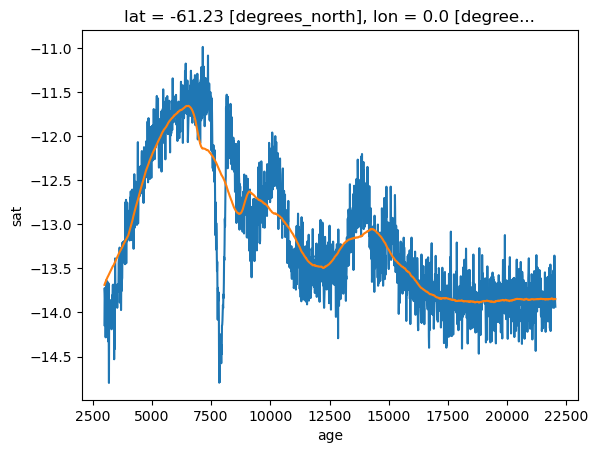

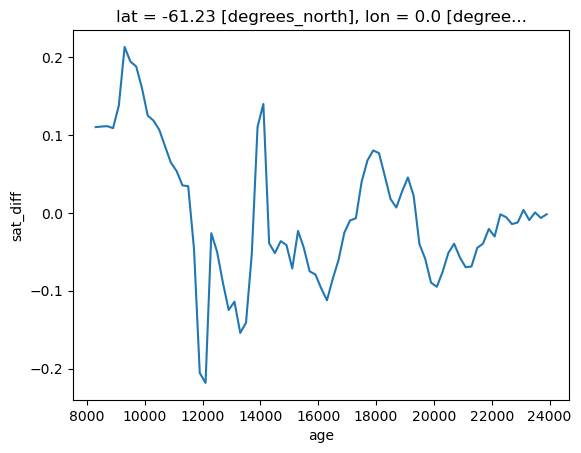

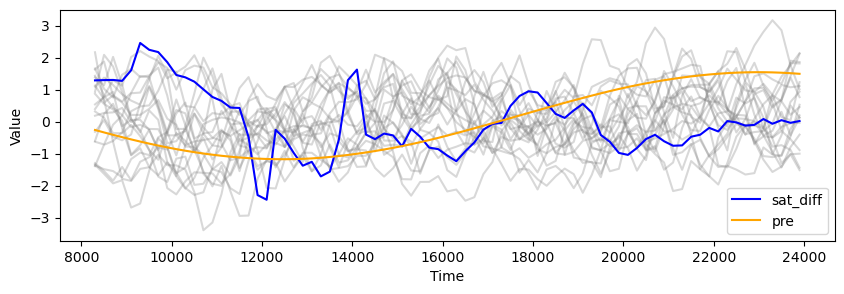

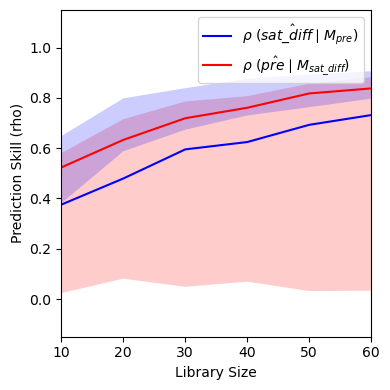

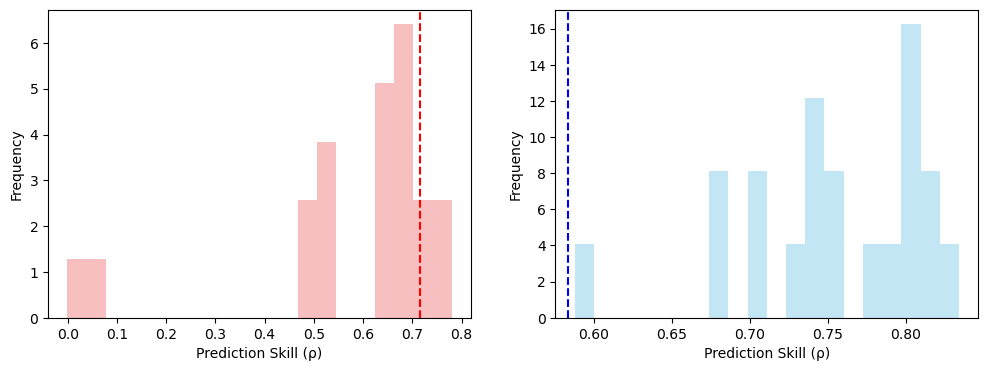

(False, False)


CCM v3:   0%|          | 0/4608 [00:00<?, ?it/s]

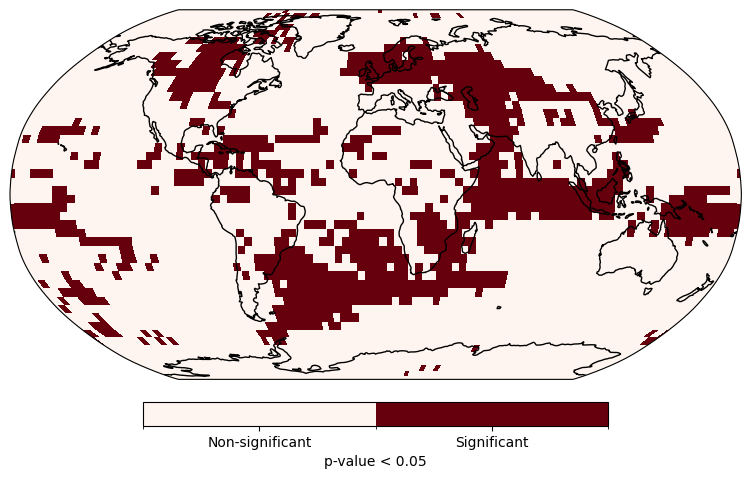

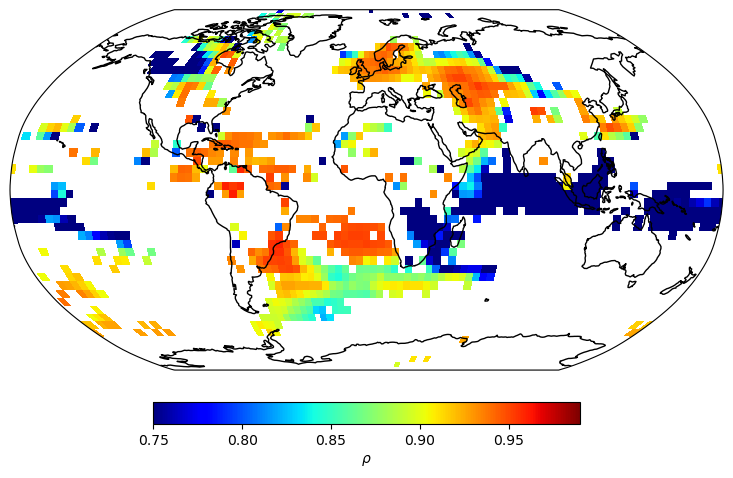

In [107]:
import pandas as pd

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

ds_fwf,fwf_pre=process_TraCE_data(nc_path= 'E:/TraCE_original_data/b30.00_4kaDVTn.cam2.ncrcat.ann_original_backup.nc',
                        df_pre=df_pre,
                        initial_age_offset=22,
                        age_start=100,
                        age_end=19000,
                        age_step=200,
                        age_offset=5000,
                        smooth_window=10)




from toolbox import significant_test as st
import importlib
importlib.reload(st)



ccm_out, ran_ccm_list_xy, test_result=st.ccm_significance_test_v3(ds_fwf, fwf_pre, lat_idx=7, lon_idx=0,
    E=5, 
    tau=-4, 
    n_ran=20, 
    libSizes="10 20 30 40 50 60",
    Tp=0,
    sample=10,
    random =True,
    flip_pre= False,
    showPlot=True
)

print(test_result)




from toolbox import significant_map  as sm
import importlib
importlib.reload(sm)
import pickle


sig_map,rho_map=sm.sig_map_rho_allinone(ds_fwf, fwf_pre,
                                   E=5, tau=-4, Tp=0, libSizes="10 20 30 40 50 60",
                                   n_ran=100, sample=10, random=True, function='v3', mode='bi', show_figure=True)



from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

processed_rho_map=cm.postprocess_rho_map(rho_map, sig_map)
cm.plot_rho_map(processed_rho_map, ds_fwf, v_range=[0.75, 0.99], color_map='jet')

# save processed_rho_map_Tp0_uncertainty_ana
with open("output/processed_rho_map_Tp0_TraCE_fwf.pkl", "wb") as f:
    pickle.dump(processed_rho_map, f)

# All

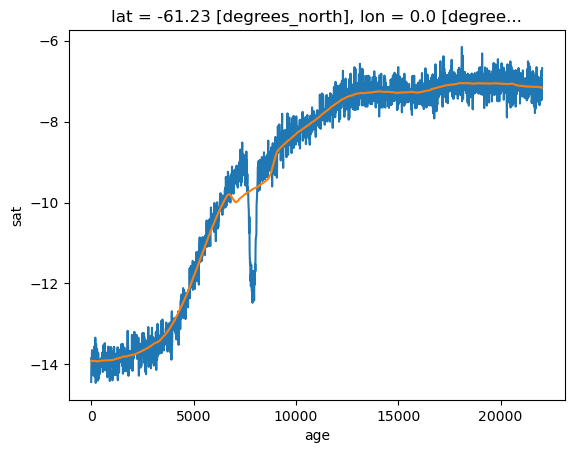

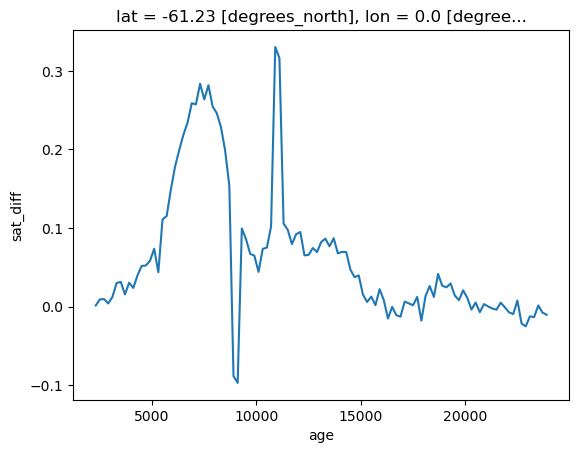

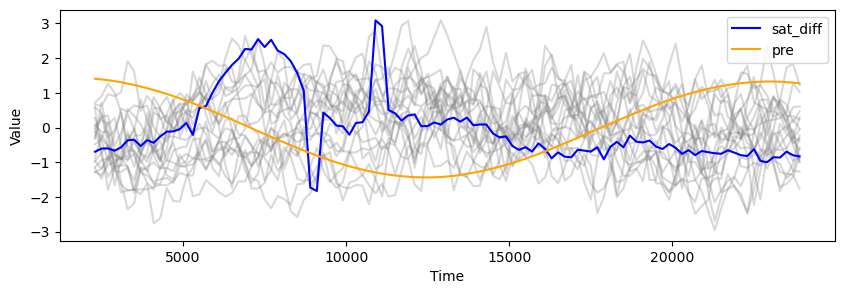

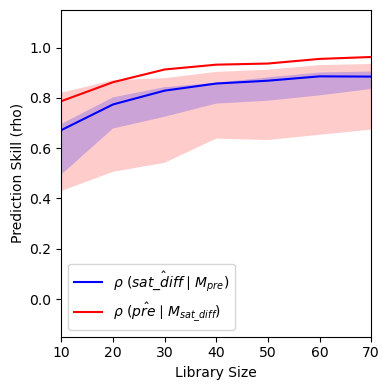

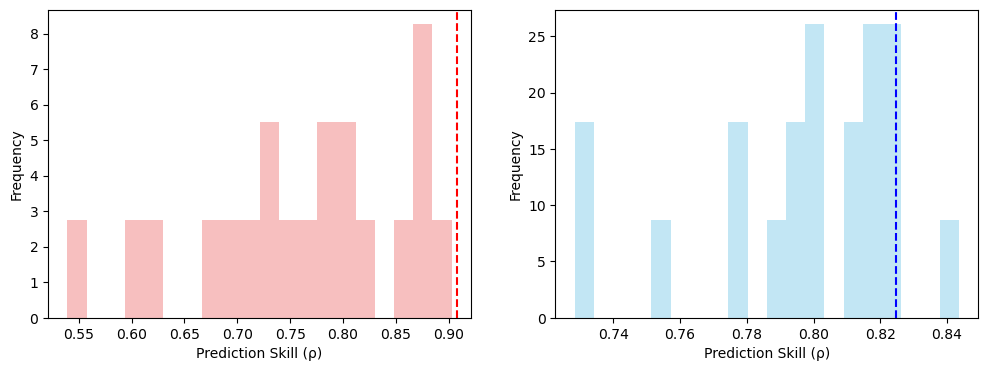

(True, False)


CCM v3:   0%|          | 0/4608 [00:00<?, ?it/s]

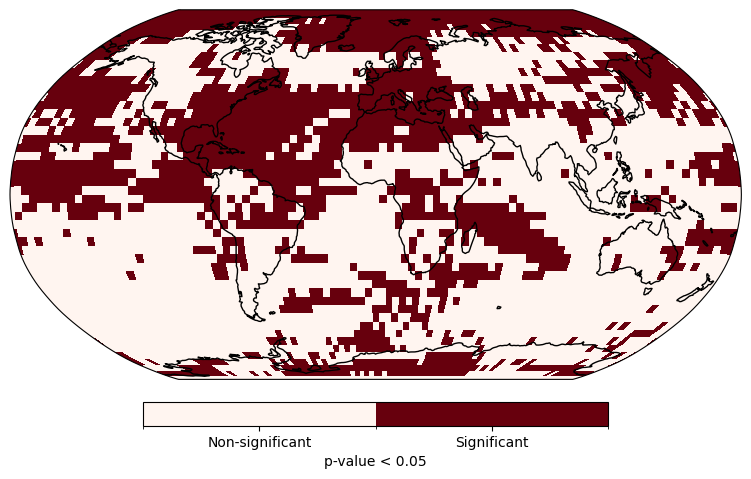

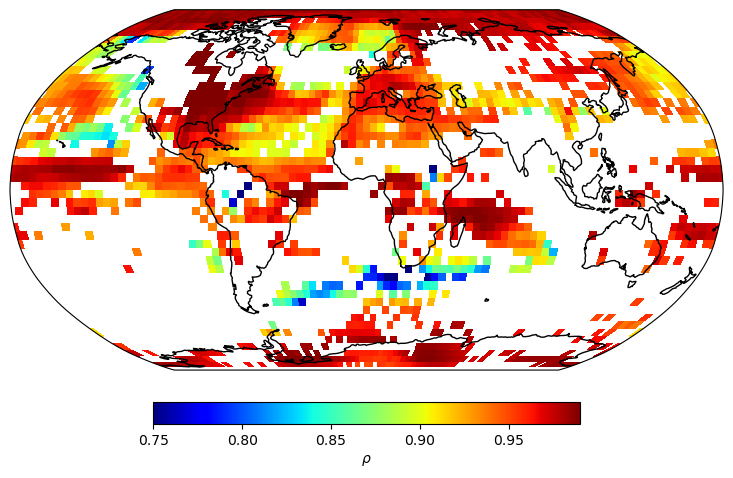

In [108]:
import pandas as pd

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

ds_all,all_pre=process_TraCE_data(nc_path= 'D:/VScode/Last_deglaciation/TraCE_data/trace.01-36.22000BP.cam2.TREFHT.22000BP_decavg_400BCE.nc',
                        df_pre=df_pre,
                        initial_age_offset=22,
                        age_start=100,
                        age_end=22000,
                        age_step=200,
                        age_offset=2000,
                        smooth_window=10)




from toolbox import significant_test as st
import importlib
importlib.reload(st)



ccm_out, ran_ccm_list_xy, test_result=st.ccm_significance_test_v3(ds_all, all_pre, lat_idx=7, lon_idx=0,
    E=5, 
    tau=-4, 
    n_ran=20, 
    libSizes="10 20 30 40 50 60 70",
    Tp=0,
    sample=10,
    random =True,
    flip_pre= False,
    showPlot=True
)

print(test_result)



from toolbox import significant_map  as sm
import importlib
importlib.reload(sm)
import pickle


sig_map,rho_map=sm.sig_map_rho_allinone(ds_all, all_pre,
                                   E=5, tau=-4, Tp=0, libSizes="10 20 30 40 50 60 70",
                                   n_ran=100, sample=10, random=True, function='v3', mode='bi', show_figure=True)



from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

processed_rho_map=cm.postprocess_rho_map(rho_map, sig_map)
cm.plot_rho_map(processed_rho_map, ds_all, v_range=[0.75, 0.99], color_map='jet')

# save processed_rho_map_Tp0_uncertainty_ana
with open("output/processed_rho_map_Tp0_TraCE_all.pkl", "wb") as f:
    pickle.dump(processed_rho_map, f)

In [3]:

import xarray as xr
import pandas as pd
import numpy as np


ds_sat_trace_all_diff = xr.open_dataset('TraCE_data/ds_sat_trace_all_diff.nc')
ds_sat_trace_fwf_diff = xr.open_dataset('TraCE_data/ds_sat_trace_fwf_diff.nc')
ds_sat_trace_ghg_diff = xr.open_dataset('TraCE_data/ds_sat_trace_ghg_diff.nc')
ds_sat_trace_orb_diff = xr.open_dataset('TraCE_data/ds_sat_trace_orb_diff.nc')
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# All

Processed grid point: lat index=0, lon index=0, max_rho=0.8076399964809824
Processed grid point: lat index=0, lon index=1, max_rho=0.8110504521966933
Processed grid point: lat index=0, lon index=2, max_rho=0.8144135319017829
Processed grid point: lat index=0, lon index=3, max_rho=0.8150456399384339
Processed grid point: lat index=0, lon index=4, max_rho=0.8172099697566303
Processed grid point: lat index=0, lon index=5, max_rho=0.8174291026084202
Processed grid point: lat index=0, lon index=6, max_rho=0.8226662957347104
Processed grid point: lat index=0, lon index=7, max_rho=0.822806643962247
Processed grid point: lat index=0, lon index=8, max_rho=0.8281290322496057
Processed grid point: lat index=0, lon index=9, max_rho=0.8272693404874778
Processed grid point: lat index=0, lon index=10, max_rho=0.8327066462347832
Processed grid point: lat index=0, lon index=11, max_rho=0.8376561820184832
Processed grid point: lat index=0, lon index=12, max_rho=0.841697834967657
Processed grid point: la

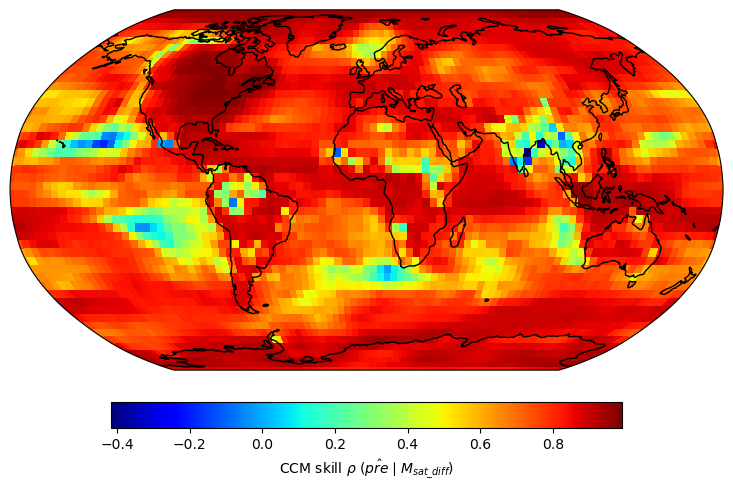

In [2]:
df_pre_TraCE = df_pre.copy()
# crop the df_pre_all to the same time period as ds_sat_trace_all_diff
df_pre_TraCE = df_pre_TraCE[(df_pre_TraCE['age'] >= ds_sat_trace_all_diff.age[0].values) &
                         (df_pre_TraCE['age'] <= ds_sat_trace_all_diff.age[-1].values)]


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

TraCE_all_rho_map_sat_diff_xmap_pre=cm.cal_raw_ccm_map(ds_sat_trace_all_diff, df_pre_TraCE, column_name='sat_diff', E=5, tau=-4, Tp=0,libSizes = "10 20 30 40 50 60 70", sample=20, random=True,v_range='auto',show_plot=True, dpi=100)


import pickle

with open('output/TraCE_all_rho_map_sat_diff_xmap_pre.pkl', 'wb') as f:
    pickle.dump(TraCE_all_rho_map_sat_diff_xmap_pre, f)

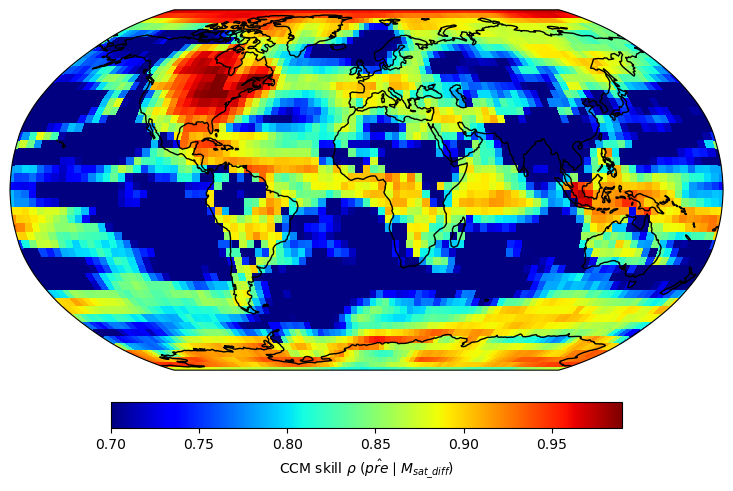

In [3]:
import pickle

# load TraCE_all_rho_map_sat_diff_xmap_pre
with open('output/TraCE_all_rho_map_sat_diff_xmap_pre.pkl', 'rb') as f:
    TraCE_all_rho_map_sat_diff_xmap_pre = pickle.load(f)

from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)


cm.plot_rho_map(TraCE_all_rho_map_sat_diff_xmap_pre, ds_sat_trace_orb_diff, v_range=[0.7, 0.99], color_map='jet')

# Orb

Processed grid point: lat index=0, lon index=0, max_rho=-0.05304215512005729
Processed grid point: lat index=0, lon index=1, max_rho=-0.050219914694393686
Processed grid point: lat index=0, lon index=2, max_rho=-0.06162861317841227
Processed grid point: lat index=0, lon index=3, max_rho=-0.04427572957450759
Processed grid point: lat index=0, lon index=4, max_rho=-0.03273712318605755
Processed grid point: lat index=0, lon index=5, max_rho=-0.03525915680408058
Processed grid point: lat index=0, lon index=6, max_rho=-0.04498479274755461
Processed grid point: lat index=0, lon index=7, max_rho=-0.06649238260429106
Processed grid point: lat index=0, lon index=8, max_rho=-0.025729274684282412
Processed grid point: lat index=0, lon index=9, max_rho=0.05472408175504495
Processed grid point: lat index=0, lon index=10, max_rho=0.08739619394505065
Processed grid point: lat index=0, lon index=11, max_rho=0.10661272095061265
Processed grid point: lat index=0, lon index=12, max_rho=0.1314772815464230

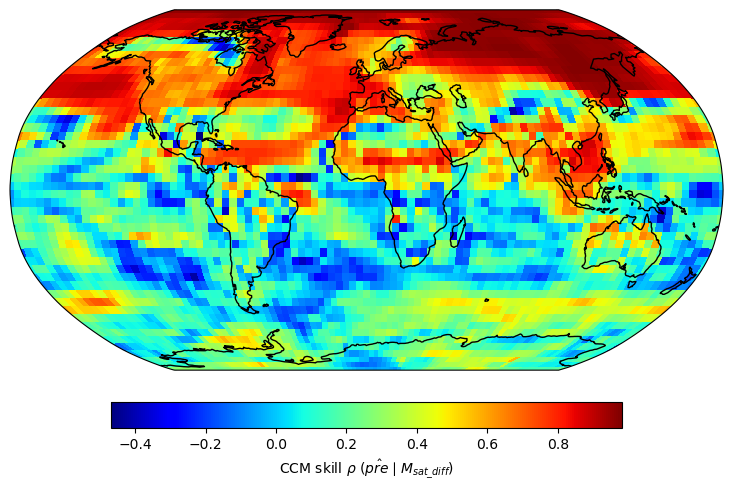

In [6]:
df_pre_TraCE = df_pre.copy()
# crop the df_pre_all to the same time period as ds_sat_trace_all_diff
df_pre_TraCE = df_pre_TraCE[(df_pre_TraCE['age'] >= ds_sat_trace_orb_diff.age[0].values) &
                         (df_pre_TraCE['age'] <= ds_sat_trace_orb_diff.age[-1].values)]


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

TraCE_orb_rho_map_sat_diff_xmap_pre=cm.cal_raw_ccm_map(ds_sat_trace_orb_diff, df_pre_TraCE, column_name='sat_diff', E=5, tau=-4, Tp=0,libSizes = "10 20 30 40 50 60 70", sample=20, random=True,v_range='auto',show_plot=True, dpi=100)


import pickle

with open('output/TraCE_orb_rho_map_sat_diff_xmap_pre.pkl', 'wb') as f:
    pickle.dump(TraCE_orb_rho_map_sat_diff_xmap_pre, f)

# GHG

Processed grid point: lat index=0, lon index=0, max_rho=0.7559752439825692
Processed grid point: lat index=0, lon index=1, max_rho=0.7582998035618643
Processed grid point: lat index=0, lon index=2, max_rho=0.7677233840324018
Processed grid point: lat index=0, lon index=3, max_rho=0.7578934154418678
Processed grid point: lat index=0, lon index=4, max_rho=0.7623895058236021
Processed grid point: lat index=0, lon index=5, max_rho=0.7653095054753469
Processed grid point: lat index=0, lon index=6, max_rho=0.7687540189436481
Processed grid point: lat index=0, lon index=7, max_rho=0.7759627373307524
Processed grid point: lat index=0, lon index=8, max_rho=0.778069218973336
Processed grid point: lat index=0, lon index=9, max_rho=0.7787534430641051
Processed grid point: lat index=0, lon index=10, max_rho=0.7706606152754685
Processed grid point: lat index=0, lon index=11, max_rho=0.7790088430330824
Processed grid point: lat index=0, lon index=12, max_rho=0.7840750324378896
Processed grid point: l

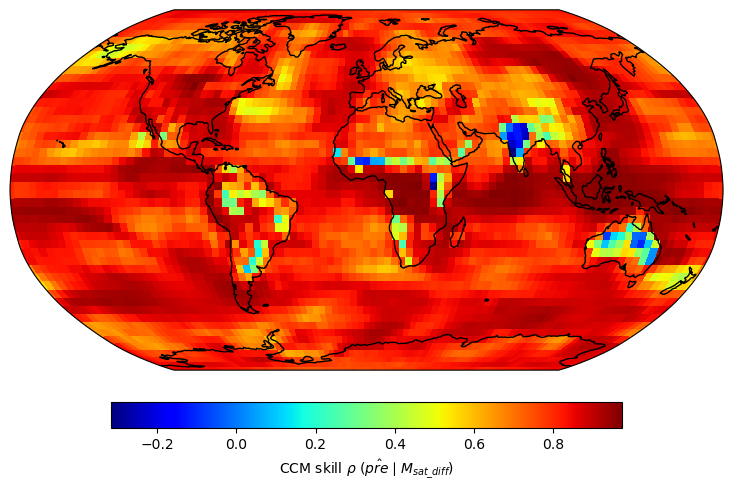

In [7]:
df_pre_TraCE = df_pre.copy()
# crop the df_pre_all to the same time period as ds_sat_trace_all_diff
df_pre_TraCE = df_pre_TraCE[(df_pre_TraCE['age'] >= ds_sat_trace_ghg_diff.age[0].values) &
                         (df_pre_TraCE['age'] <= ds_sat_trace_ghg_diff.age[-1].values)]


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

TraCE_ghg_rho_map_sat_diff_xmap_pre=cm.cal_raw_ccm_map(ds_sat_trace_ghg_diff, df_pre_TraCE, column_name='sat_diff', E=5, tau=-4, Tp=0,libSizes = "10 20 30 40 50 60 70", sample=20, random=True,v_range='auto',show_plot=True, dpi=100)


import pickle

with open('output/TraCE_ghg_rho_map_sat_diff_xmap_pre.pkl', 'wb') as f:
    pickle.dump(TraCE_ghg_rho_map_sat_diff_xmap_pre, f)

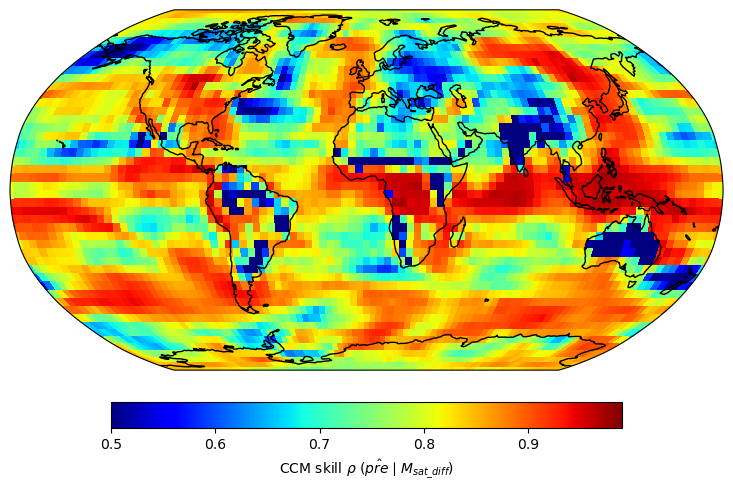

In [10]:
import pickle

# load TraCE_all_rho_map_sat_diff_xmap_pre
with open('output/TraCE_ghg_rho_map_sat_diff_xmap_pre.pkl', 'rb') as f:
    TraCE_ghg_rho_map_sat_diff_xmap_pre = pickle.load(f)

from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)


cm.plot_rho_map(TraCE_ghg_rho_map_sat_diff_xmap_pre, ds_sat_trace_ghg_diff, v_range=[0.5, 0.99], color_map='jet')

# FWF

Processed grid point: lat index=0, lon index=0, max_rho=-0.04571507989217159
Processed grid point: lat index=0, lon index=1, max_rho=-0.059084880192800684
Processed grid point: lat index=0, lon index=2, max_rho=-0.053537694801681635
Processed grid point: lat index=0, lon index=3, max_rho=-0.029337684185374035
Processed grid point: lat index=0, lon index=4, max_rho=-0.04890428938038281
Processed grid point: lat index=0, lon index=5, max_rho=-0.0550424951127098
Processed grid point: lat index=0, lon index=6, max_rho=-0.05142180584085162
Processed grid point: lat index=0, lon index=7, max_rho=-0.06284539426514321
Processed grid point: lat index=0, lon index=8, max_rho=-0.09992187947284177
Processed grid point: lat index=0, lon index=9, max_rho=-0.08380998244772887
Processed grid point: lat index=0, lon index=10, max_rho=-0.08299601614789191
Processed grid point: lat index=0, lon index=11, max_rho=-0.09359167563614186
Processed grid point: lat index=0, lon index=12, max_rho=-0.104456802908

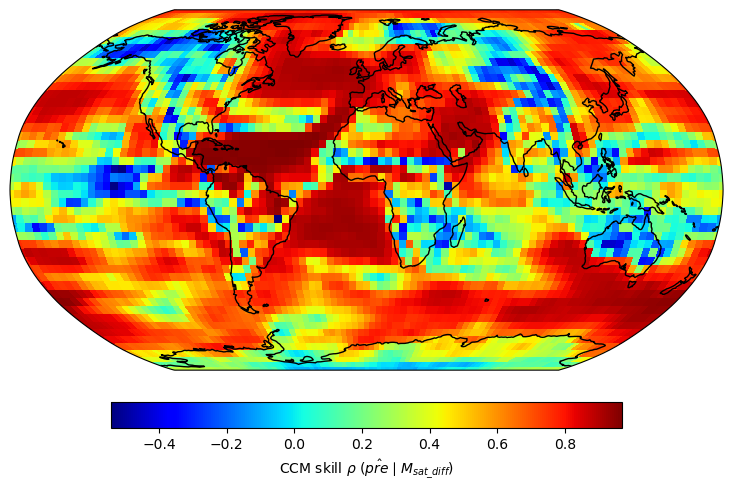

In [4]:
df_pre_TraCE = df_pre.copy()
# crop the df_pre_all to the same time period as ds_sat_trace_all_diff
df_pre_TraCE = df_pre_TraCE[(df_pre_TraCE['age'] >= ds_sat_trace_fwf_diff.age[0].values) &
                         (df_pre_TraCE['age'] <= ds_sat_trace_fwf_diff.age[-1].values)]


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

TraCE_fwf_rho_map_sat_diff_xmap_pre=cm.cal_raw_ccm_map(ds_sat_trace_fwf_diff, df_pre_TraCE, column_name='sat_diff', E=5, tau=-4, Tp=0,libSizes = "10 20 30 40 50 60 70", sample=20, random=True,v_range='auto',show_plot=True, dpi=100)


import pickle

with open('output/TraCE_fwf_rho_map_sat_diff_xmap_pre.pkl', 'wb') as f:
    pickle.dump(TraCE_fwf_rho_map_sat_diff_xmap_pre, f)

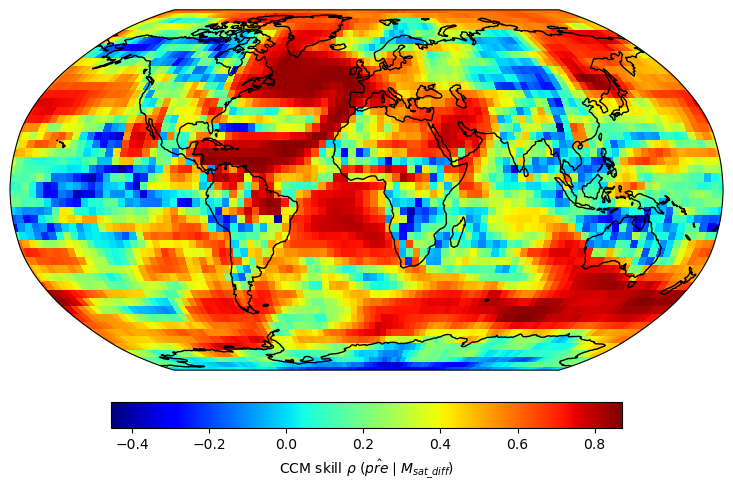

In [4]:
import pickle

# load TraCE_all_rho_map_sat_diff_xmap_pre
with open('output/TraCE_fwf_rho_map_sat_diff_xmap_pre.pkl', 'rb') as f:
    TraCE_fwf_rho_map_sat_diff_xmap_pre = pickle.load(f)

from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)


cm.plot_rho_map(TraCE_fwf_rho_map_sat_diff_xmap_pre, ds_sat_trace_orb_diff, v_range='auto', color_map='jet')

Processed grid point: lat index=0, lon index=0, max_rho=-0.257384088899585
Processed grid point: lat index=0, lon index=1, max_rho=-0.27927788404996984
Processed grid point: lat index=0, lon index=2, max_rho=-0.2777690901466402
Processed grid point: lat index=0, lon index=3, max_rho=-0.28311992083477366
Processed grid point: lat index=0, lon index=4, max_rho=-0.28829364449008826
Processed grid point: lat index=0, lon index=5, max_rho=-0.29287479959493623
Processed grid point: lat index=0, lon index=6, max_rho=-0.28775396772026196
Processed grid point: lat index=0, lon index=7, max_rho=-0.2884585360529511
Processed grid point: lat index=0, lon index=8, max_rho=-0.28478932416227476
Processed grid point: lat index=0, lon index=9, max_rho=-0.2750141148030141
Processed grid point: lat index=0, lon index=10, max_rho=-0.2745342357667149
Processed grid point: lat index=0, lon index=11, max_rho=-0.2332343409429904
Processed grid point: lat index=0, lon index=12, max_rho=-0.2120395937811212
Proc

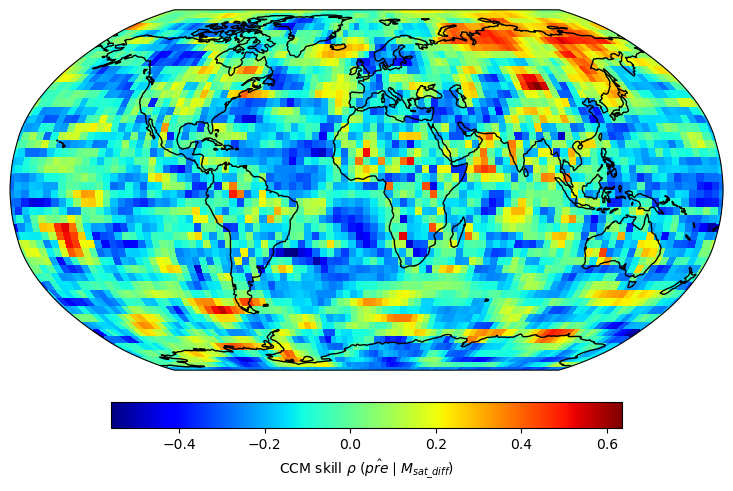

In [4]:
df_pre_TraCE = df_pre.copy()
# crop the df_pre_all to the same time period as ds_sat_trace_all_diff
df_pre_TraCE = df_pre_TraCE[(df_pre_TraCE['age'] >= ds_sat_trace_orb_diff.age[0].values) &
                         (df_pre_TraCE['age'] <= ds_sat_trace_orb_diff.age[-1].values)]


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

TraCE_all_rho_map_orb_diff_xmap_pre=cm.cal_raw_ccm_map(ds_sat_trace_orb_diff, df_pre_TraCE, column_name='sat_diff', E=5, tau=-4, Tp=0,libSizes = "10 20 30 40 50 60 70", sample=20, random=True,v_range='auto',show_plot=True, dpi=100)


import pickle

with open('output/TraCE_all_rho_map_orb_diff_xmap_pre.pkl', 'wb') as f:
    pickle.dump(TraCE_all_rho_map_orb_diff_xmap_pre, f)

In [ ]:

import xarray as xr
import pandas as pd



ds_sat_trace_orb = xr.open_dataset('TraCE_data/ds_sat_trace_orb.nc')

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")
# drop rows in df_pre with age>=22000
df_pre_short = df_pre[df_pre['age'] < 22000].copy()
df_pre_short

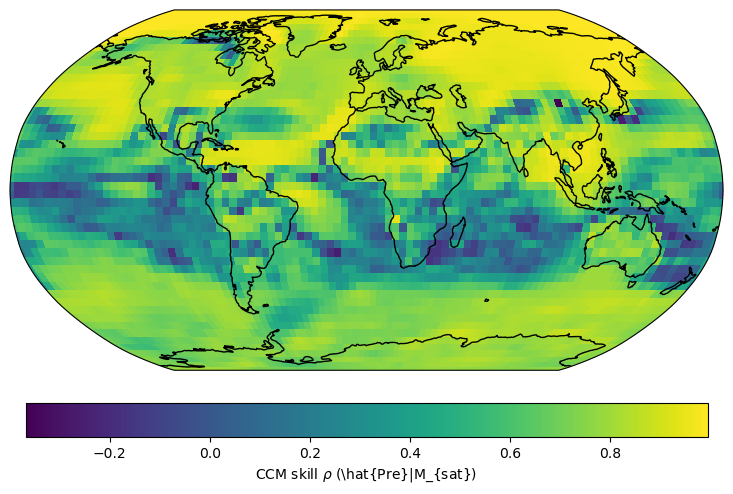

In [13]:
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

rwa_rho_map_Tp0=ccm_map.cal_raw_ccm_map(ds_sat=ds_sat_trace_orb, df_pre= df_pre_short, E=4, tau=3, Tp=0)

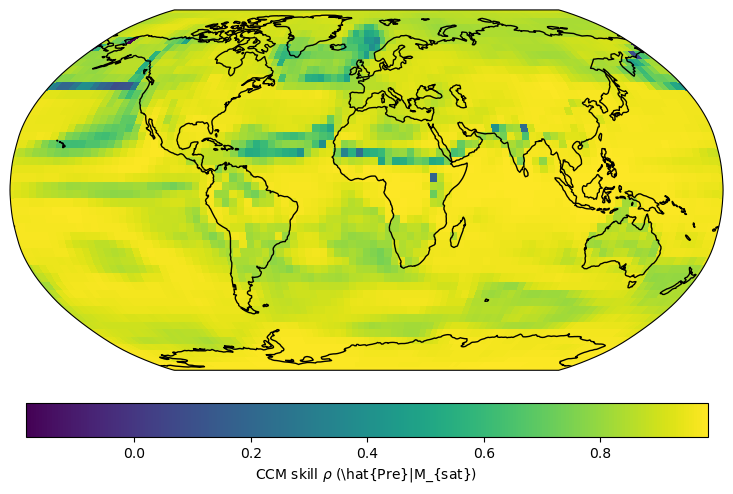

In [15]:
ds_sat_trace_all = xr.open_dataset('TraCE_data/ds_sat_trace_all.nc')

from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

rwa_rho_map_Tp0=ccm_map.cal_raw_ccm_map(ds_sat=ds_sat_trace_all, df_pre= df_pre_short, E=4, tau=3, Tp=0)

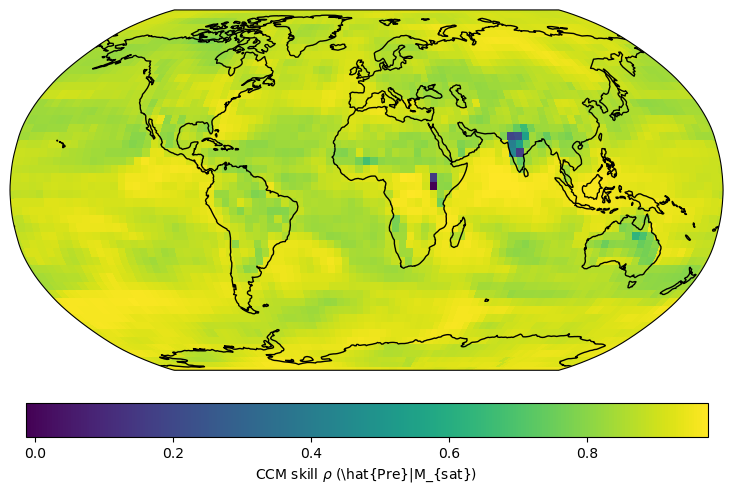

In [16]:
ds_sat_trace_ghg = xr.open_dataset('TraCE_data/ds_sat_trace_ghg.nc')

from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

rwa_rho_map_Tp0=ccm_map.cal_raw_ccm_map(ds_sat=ds_sat_trace_ghg, df_pre= df_pre_short, E=4, tau=3, Tp=0)

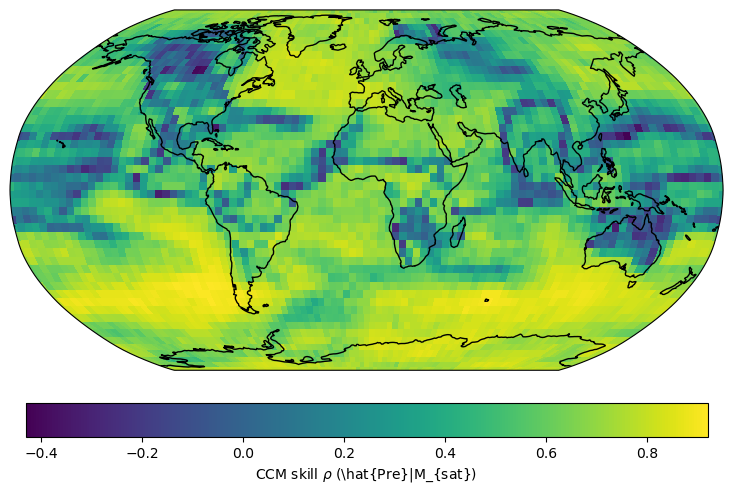

In [ ]:
ds_sat_trace_fwf = xr.open_dataset('TraCE_data/ds_sat_trace_fwf.nc')
 
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

rwa_rho_map_Tp0=ccm_map.cal_raw_ccm_map(ds_sat=ds_sat_trace_fwf, df_pre= df_pre_short, E=4, tau=3, Tp=0)

# Sat Xmapping CO2

In [22]:

import xarray as xr
import pandas as pd


ds_sat = xr.open_dataset('LGMR_data/ds_sat_flipped.nc')
ds_sat.info()

df_co2 = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\co2.csv")

# rename the second column to 'pre'
df_co2.columns = ['age', 'pre']

xarray.Dataset {
dimensions:
	lat = 96 ;
	lon = 144 ;
	age = 120 ;

variables:
	float32 lat(lat) ;
		lat:FillValue = 9.969209968386869e+36 ;
		lat:long_name = vector latitudes ;
		lat:units = degrees_north ;
	float32 lon(lon) ;
		lon:FillValue = 9.969209968386869e+36 ;
		lon:long_name = vector of longitudes ;
		lon:units = degrees_east ;
	float32 age(age) ;
	float32 sat(age, lat, lon) ;
		sat:FillValue = 9.969209968386869e+36 ;
		sat:long_name = ENSEMBLE MEAN (n = 500) mean annual temperature at reference height ;
		sat:units = degrees Celsius ;
	float32 sat_std(age, lat, lon) ;
		sat_std:FillValue = 9.969209968386869e+36 ;
		sat_std:long_name = ENSEMBLE STANDARD DEVIATION (n = 500) mean annual temperature at reference height ;
		sat_std:units = degrees Celsius ;

// global attributes:
}

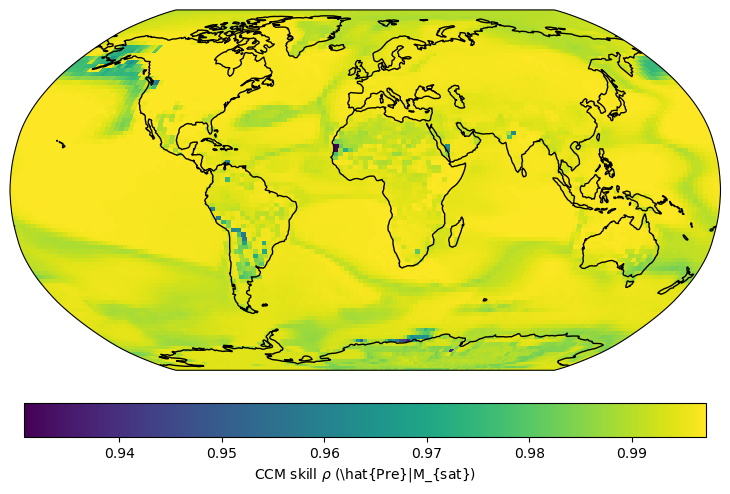

In [23]:
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

rwa_rho_map_Tp0=ccm_map.cal_raw_ccm_map(ds_sat=ds_sat, df_pre= df_co2, E=4, tau=3, Tp=0)